# パッケージインストール

In [ ]:
!pip install -q transformers==4.57.1
!pip install -q decord==0.6.0
!pip install -q lmdb==1.7.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 149.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 9.5 MB/s eta 0:00:00


In [ ]:
# MagiAttention（Hopper / Blackwell GPUのみ、MTP推論の高速化に推奨）
# !git clone https://github.com/SandAI-org/MagiAttention.git
# %cd MagiAttention
# !git checkout v1.0.5
# !git submodule update --init --recursive
# !pip install -r requirements.txt
# !pip install --no-build-isolation .

# LocateAnything Utility func

In [ ]:
import re
import torch
from PIL import Image
from transformers import AutoModel, AutoTokenizer, AutoProcessor


class LocateAnythingWorker:
    """Stateful worker that loads the model once and serves perception queries."""

    def __init__(self, model_path: str, device: str = "cuda", dtype=torch.bfloat16):
        self.device = device
        self.dtype = dtype

        self.tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
        self.processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)
        self.model = AutoModel.from_pretrained(
            model_path,
            torch_dtype=dtype,
            trust_remote_code=True,
        ).to(device).eval()

    @torch.no_grad()
    def predict(
        self,
        image: Image.Image,
        question: str,
        generation_mode: str = "hybrid",   # "fast" (MTP) | "slow" (NTP/AR) | "hybrid"
        max_new_tokens: int = 2048,
        temperature: float = 0.7,
        verbose: bool = True,
    ) -> dict:
        messages = [
            {"role": "user", "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": question},
            ]}
        ]

        text = self.processor.py_apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        images, videos = self.processor.process_vision_info(messages)
        inputs = self.processor(
            text=[text], images=images, videos=videos, return_tensors="pt"
        ).to(self.device)

        pixel_values = inputs["pixel_values"].to(self.dtype)
        input_ids = inputs["input_ids"]
        image_grid_hws = inputs.get("image_grid_hws", None)

        response = self.model.generate(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=inputs["attention_mask"],
            image_grid_hws=image_grid_hws,
            tokenizer=self.tokenizer,
            max_new_tokens=max_new_tokens,
            use_cache=True,
            generation_mode=generation_mode,
            temperature=temperature,
            do_sample=True,
            top_p=0.9,
            repetition_penalty=1.1,
            verbose=verbose,
        )

        result = {"answer": response[0] if isinstance(response, tuple) else response}
        if isinstance(response, tuple) and len(response) >= 3:
            result["history"] = response[1]
            result["stats"] = response[2]
        return result

    # ---- Convenience methods for each task ----

    def detect(self, image: Image.Image, categories: list[str], **kwargs) -> dict:
        """Object detection / document layout analysis."""
        cats = "</c>".join(categories)
        prompt = f"Locate all the instances that matches the following description: {cats}."
        return self.predict(image, prompt, **kwargs)

    def ground_single(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Phrase grounding — single instance."""
        prompt = f"Locate a single instance that matches the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def ground_multi(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Phrase grounding — multiple instances."""
        prompt = f"Locate all the instances that match the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def ground_text(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Text grounding."""
        prompt = f"Please locate the text referred as {phrase}."
        return self.predict(image, prompt, **kwargs)

    def detect_text(self, image: Image.Image, **kwargs) -> dict:
        """Scene text detection."""
        prompt = "Detect all the text in box format."
        return self.predict(image, prompt, **kwargs)

    def ground_gui(self, image: Image.Image, phrase: str, output_type: str = "box", **kwargs) -> dict:
        """GUI grounding (box or point)."""
        if output_type == "point":
            prompt = f"Point to: {phrase}."
        else:
            prompt = f"Locate the region that matches the following description: {phrase}."
        return self.predict(image, prompt, **kwargs)

    def point(self, image: Image.Image, phrase: str, **kwargs) -> dict:
        """Pointing."""
        prompt = f"Point to: {phrase}."
        return self.predict(image, prompt, **kwargs)

    # ---- Utility: parse model output ----

    @staticmethod
    def parse_boxes(answer: str, image_width: int, image_height: int) -> list[dict]:
        """Parse model output into pixel-coordinate bounding boxes with labels.

        Coordinates in model output are normalized integers in [0, 1000].

        Example:
            <ref>person</ref><box><54><281><114><516></box>
            <ref>car</ref><box><671><317><848><594></box>
        """
        boxes = []
        current_label = None

        pattern = r"<ref>(.*?)</ref>|<box><(\d+)><(\d+)><(\d+)><(\d+)></box>"

        for m in re.finditer(pattern, answer):
            label, x1, y1, x2, y2 = m.groups()

            if label is not None:
                current_label = label
                continue

            boxes.append({
                "label": current_label,
                "x1": int(x1) / 1000 * image_width,
                "y1": int(y1) / 1000 * image_height,
                "x2": int(x2) / 1000 * image_width,
                "y2": int(y2) / 1000 * image_height,
            })

        return boxes

    @staticmethod
    def parse_points(answer: str, image_width: int, image_height: int) -> list[dict]:
        """Parse model output into pixel-coordinate points with labels."""

        points = []
        current_label = None

        pattern = r"<ref>(.*?)</ref>|<box><(\d+)><(\d+)></box>"

        for m in re.finditer(pattern, answer):
            label, x, y = m.groups()

            if label is not None:
                current_label = label
                continue

            points.append({
                "label": current_label,
                "x": int(x) / 1000 * image_width,
                "y": int(y) / 1000 * image_height,
            })

        return points


In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def visualize(image, boxes, points):
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(image)

    # Generate colors for all labels
    labels = {
        item.get("label", "unknown")
        for item in boxes + points
    }

    labels = sorted(labels)

    cmap = cm.get_cmap("tab20", max(len(labels), 1))

    label_colors = {
        label: cmap(i)
        for i, label in enumerate(labels)
    }

    # Draw Bounding Boxes
    for box in boxes:
        label = box.get("label", "unknown")
        color = label_colors[label]

        rect = patches.Rectangle(
            (box["x1"], box["y1"]),
            box["x2"] - box["x1"],
            box["y2"] - box["y1"],
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

        ax.text(
            box["x1"],
            max(0, box["y1"] - 5),
            label,
            fontsize=10,
            color="white",
            bbox={
                "facecolor": color,
                "edgecolor": color,
                "pad": 2,
            },
        )

    # Draw Points
    for pt in points:
        label = pt.get("label", "unknown")
        color = label_colors[label]

        circle = patches.Circle(
            (pt["x"], pt["y"]),
            radius=5,
            color=color,
        )
        ax.add_patch(circle)

        ax.text(
            pt["x"] + 8,
            pt["y"] - 8,
            label,
            fontsize=10,
            color="white",
            bbox={
                "facecolor": color,
                "edgecolor": color,
                "pad": 2,
            },
        )

    plt.axis("off")
    plt.show()

# モデル読み込み

In [ ]:
worker = LocateAnythingWorker("nvidia/LocateAnything-3B")

Qwen2ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

# 画像読み込み

In [ ]:
img = Image.open("example.jpg").convert("RGB")

In [ ]:
%%time
# Object Detection
result = worker.detect(img, ["person", "car", "bicycle"])

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=179; generate_time(s)=3.7154; tps=48.1779; forward_step=55; num_boxes=28; bps=7.5362; prefill_time=0.6383; switch_to_ar=6

CPU times: user 3.78 s, sys: 0 ns, total: 3.78 s
Wall time: 3.73 s


/tmp/ipykernel_1244/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


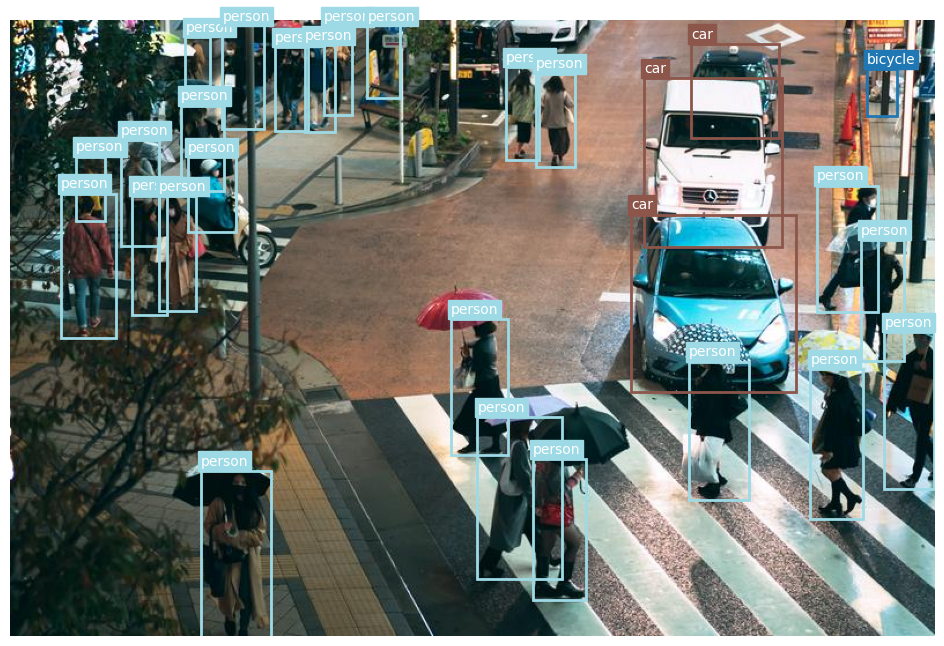

In [ ]:
visualize(img, boxes, points)

In [ ]:
%%time
# Phrase Grounding (multiple)
result = worker.ground_multi(img, "people wearing red shirts")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)

/root/.cache/huggingface/modules/transformers_modules/nvidia/LocateAnything_hyphen_3B/7a81d810571dc5f244b2f0b6868128f24b1cbd85/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=25; generate_time(s)=1.1407; tps=21.9157; forward_step=10; num_boxes=3; bps=2.6299; prefill_time=0.6415; switch_to_ar=1

CPU times: user 1.2 s, sys: 0 ns, total: 1.2 s
Wall time: 1.16 s


/tmp/ipykernel_1244/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


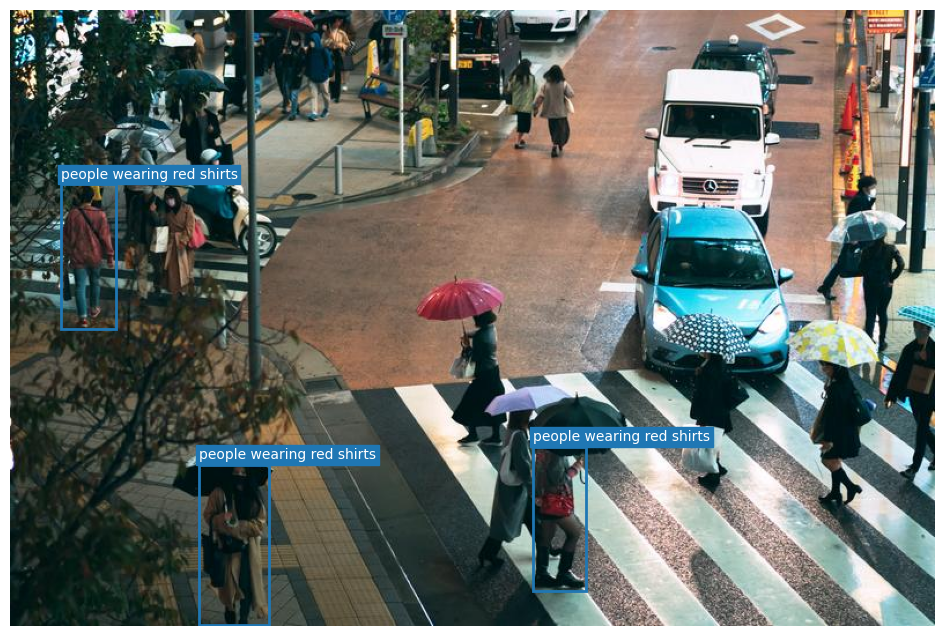

In [ ]:
visualize(img, boxes, points)

In [ ]:
%%time
# Scene Text Detection
result = worker.detect_text(img)

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=10; generate_time(s)=0.7648; tps=13.0759; forward_step=3; num_boxes=1; bps=1.3076; prefill_time=0.6390; switch_to_ar=0

CPU times: user 828 ms, sys: 0 ns, total: 828 ms
Wall time: 785 ms


/root/.cache/huggingface/modules/transformers_modules/nvidia/LocateAnything_hyphen_3B/7a81d810571dc5f244b2f0b6868128f24b1cbd85/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))


/tmp/ipykernel_1244/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


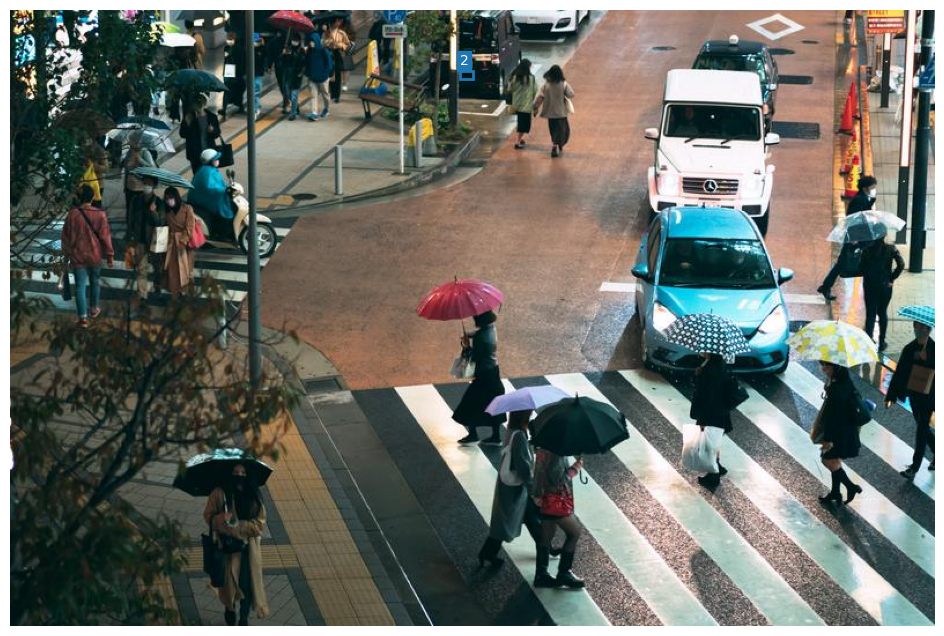

In [ ]:
visualize(img, boxes, points)

In [ ]:
%%time
# Pointing
result = worker.point(img, "the traffic sign")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)

/root/.cache/huggingface/modules/transformers_modules/nvidia/LocateAnything_hyphen_3B/7a81d810571dc5f244b2f0b6868128f24b1cbd85/generate_utils.py:186: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  box_avg.append(torch.tensor(out_ref, dtype=x0.dtype, device=x0.device))



Statistic Info, num_tokens=14; generate_time(s)=0.9619; tps=14.5552; forward_step=7; num_boxes=2; bps=2.0793; prefill_time=0.6412; switch_to_ar=1

CPU times: user 1.03 s, sys: 705 µs, total: 1.03 s
Wall time: 984 ms


/tmp/ipykernel_1244/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


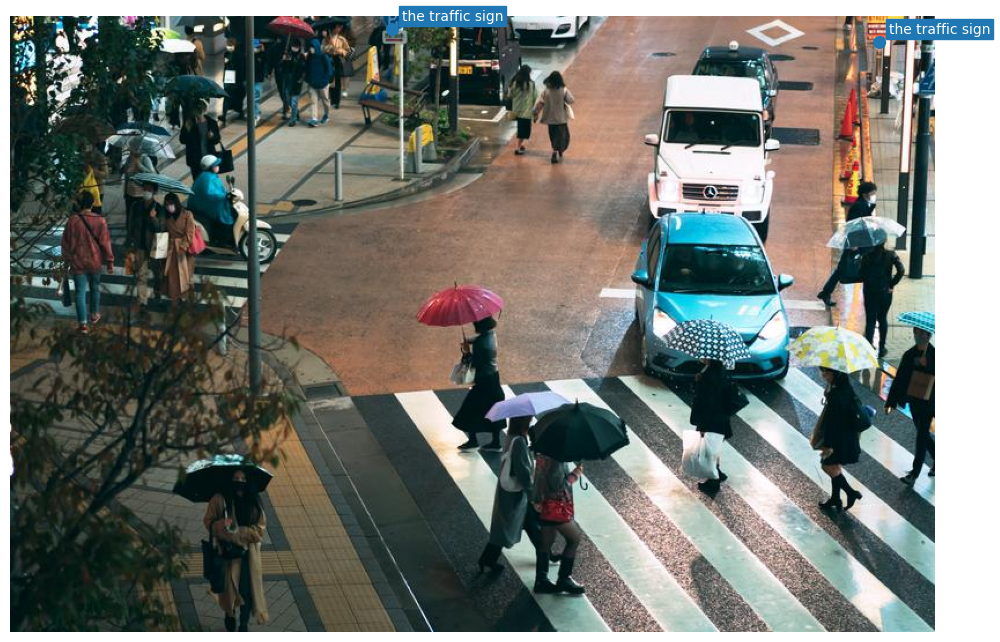

In [ ]:
visualize(img, boxes, points)

In [ ]:
%%time
# GUI Grounding (point)
result = worker.ground_gui(img, "Mercedes-Benz symbol", output_type="point")

# Parse structured output into pixel coordinates
w, h = img.size
boxes = LocateAnythingWorker.parse_boxes(result["answer"], w, h)
points = LocateAnythingWorker.parse_points(result["answer"], w, h)


Statistic Info, num_tokens=11; generate_time(s)=0.7528; tps=14.6114; forward_step=3; num_boxes=1; bps=1.3283; prefill_time=0.6368; switch_to_ar=0

CPU times: user 815 ms, sys: 0 ns, total: 815 ms
Wall time: 773 ms


/tmp/ipykernel_1244/941094062.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", max(len(labels), 1))


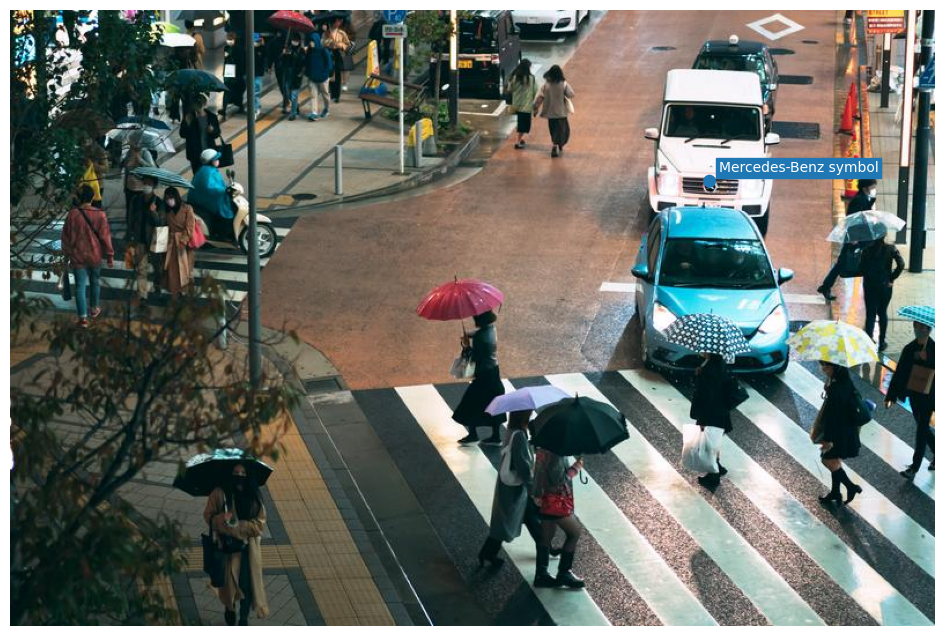

In [ ]:
visualize(img, boxes, points)